## Gait data (Pose keypoints)

In [48]:
%matplotlib widget
import json, sys
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.spatial.distance import pdist, squareform

sys.path.insert(0, str(Path(".").resolve()))
import vineyard_ext  # C++ extension: GUDHI chain matrix with vine swaps

POSE_DIR = Path("dataset_samples/pose")
MAX_EDGE_LENGTH = 300  # pixels — only include edges shorter than this
MIN_VINE_FRAMES = 5    # vine must appear in at least this many frames

KEYPOINT_NAMES = [
    "nose", "l_eye", "r_eye", "l_ear", "r_ear",
    "l_shoulder", "r_shoulder", "l_elbow", "r_elbow",
    "l_wrist", "r_wrist", "l_hip", "r_hip",
    "l_knee", "r_knee", "l_ankle", "r_ankle",
]
N_KP = len(KEYPOINT_NAMES)  # 17


def load_pose_frames(json_path):
    """Load AlphaPose JSON, return list of (frame_idx, 17x2 array) for valid frames."""
    data = json.loads(json_path.read_text())
    frames = []
    for entry in data:
        if entry["joints"] is None:
            continue
        pts = np.array([[entry["joints"][k]["x"], entry["joints"][k]["y"]] for k in KEYPOINT_NAMES])
        frames.append((entry["frame"], pts))
    return frames


def build_rips_simplices(n_points, max_edge_length, all_dist_matrices):
    """Build the union Rips complex (up to dim 2) over all frames.

    Returns (simplex_list, filtration_per_frame) ready for vineyard_ext.
    """
    simplices = [[i] for i in range(n_points)]

    # Union of edges across all frames
    edge_set = set()
    for D in all_dist_matrices:
        for i in range(n_points):
            for j in range(i + 1, n_points):
                if D[i, j] <= max_edge_length:
                    edge_set.add((i, j))
    edges = sorted(edge_set)
    for i, j in edges:
        simplices.append([i, j])

    # Triangles: add [i,j,k] if all three edges exist in the union
    edge_set_frozen = set(edges)
    for i, j in edges:
        for k in range(n_points):
            if k <= j:
                continue
            if (i, k) in edge_set_frozen and (j, k) in edge_set_frozen:
                simplices.append([i, j, k])

    # Filtration values per frame
    filtration_per_frame = []
    for D in all_dist_matrices:
        filt = [0.0] * len(simplices)
        for idx, sx in enumerate(simplices):
            if len(sx) == 2:
                filt[idx] = D[sx[0], sx[1]]
            elif len(sx) == 3:
                filt[idx] = max(D[sx[0], sx[1]], D[sx[0], sx[2]], D[sx[1], sx[2]])
        filtration_per_frame.append(filt)

    return simplices, filtration_per_frame


def extract_vines(barcodes, frame_indices, min_frames):
    """Convert per-frame barcodes into vines (tracked persistence pairs).

    The vine swap algorithm preserves bar identity across frames:
    bar i in the barcode at frame t corresponds to bar i at frame t+1.
    """
    if not barcodes:
        return [], []

    n_bars = len(barcodes[0])
    vines_h0, vines_h1 = [], []

    for bar_idx in range(n_bars):
        vine = []
        dim = None
        for frame_i, bc in enumerate(barcodes):
            if bar_idx >= len(bc):
                continue
            d, b, dth = bc[bar_idx]
            dim = d
            if np.isinf(dth):
                continue  # skip essential features
            vine.append((frame_indices[frame_i], b, dth))

        if len(vine) >= min_frames and dim is not None:
            if dim == 0:
                vines_h0.append(vine)
            elif dim == 1:
                vines_h1.append(vine)

    return vines_h0, vines_h1


def draw_vineyard_lines(ax, vines, frame_indices, color, alpha=0.6):
    if not vines:
        return
    t_min, t_max = min(frame_indices), max(frame_indices)
    t_range = t_max - t_min if t_max > t_min else 1

    for vine in vines:
        vine_sorted = sorted(vine, key=lambda x: x[0])
        births = [v[1] for v in vine_sorted]
        deaths = [v[2] for v in vine_sorted]
        diff = [(births[i]-deaths[i]) for i in range(len(vine_sorted))]
        if all(x == 0 for x in diff):
            continue
        times = [(v[0] - t_min) / t_range for v in vine_sorted]
        ax.plot(births, deaths, times, color=color, alpha=alpha, linewidth=0.8)


def visualize_pose_vineyard(json_path):
    frames = load_pose_frames(json_path)
    # frames = frames[0::10]
    if len(frames) < 2:
        return

    trial_name = json_path.stem
    condition = json_path.parent.name
    patient = json_path.parent.parent.name
    label = f"{patient}/{condition}/{trial_name}"
    print(f"  Processing {len(frames)} frames for {label}...")

    frame_indices = [f[0] for f in frames]
    all_pts = [f[1] for f in frames]
    all_dist = [squareform(pdist(pts)) for pts in all_pts]

    # Build union Rips complex
    simplices, filtration_per_frame = build_rips_simplices(N_KP, MAX_EDGE_LENGTH, all_dist)
    print(f"    Complex: {N_KP} vertices, {len(simplices)} simplices, {len(frames)} frames")

    # Compute vineyard via C++ chain matrix with vine swaps
    barcodes = vineyard_ext.compute_vineyard(simplices, filtration_per_frame)

    # Extract vines
    vines_h0, vines_h1 = extract_vines(barcodes, frame_indices, MIN_VINE_FRAMES)
    print(f"    H0 vines: {len(vines_h0)}, H1 vines: {len(vines_h1)}")

    # Plot
    fig = plt.figure(figsize=(16, 7))
    fig.suptitle(f'Vineyard (Chain Matrix) — {label}', fontsize=13, fontweight='bold')

    for subplot_idx, (dim_label, vines, color) in enumerate([
        ('H0 (Components)', vines_h0, 'steelblue'),
        ('H1 (Loops)',      vines_h1, 'tomato'),
    ]):
        ax = fig.add_subplot(1, 2, subplot_idx + 1, projection='3d')
        draw_vineyard_lines(ax, vines, frame_indices, color)

        all_vals = []
        for vine in vines:
            for _, b, d in vine:
                all_vals.extend([b, d])
        if all_vals:
            vmin, vmax = min(all_vals), max(all_vals)
            grid = np.linspace(vmin, vmax, 10)
            B, T = np.meshgrid(grid, np.linspace(0, 1, 10))
            ax.plot_surface(B, B, T, alpha=0.07, color='gray')

        ax.set_xlabel("Birth", fontsize=9, labelpad=6)
        ax.set_ylabel("Death", fontsize=9, labelpad=6)
        ax.set_zlabel("Time", fontsize=9, labelpad=6)
        ax.set_title(dim_label, fontsize=11)
        ax.tick_params(labelsize=7)
        ax.view_init(elev=25, azim=-55)

    plt.tight_layout()
    plt.show()
    print(f"  Done: {label}")

  Processing 91 frames for PA000/FGS/WJ_1_AlphaPose...
    Complex: 17 vertices, 833 simplices, 91 frames
    H0 vines: 16, H1 vines: 120


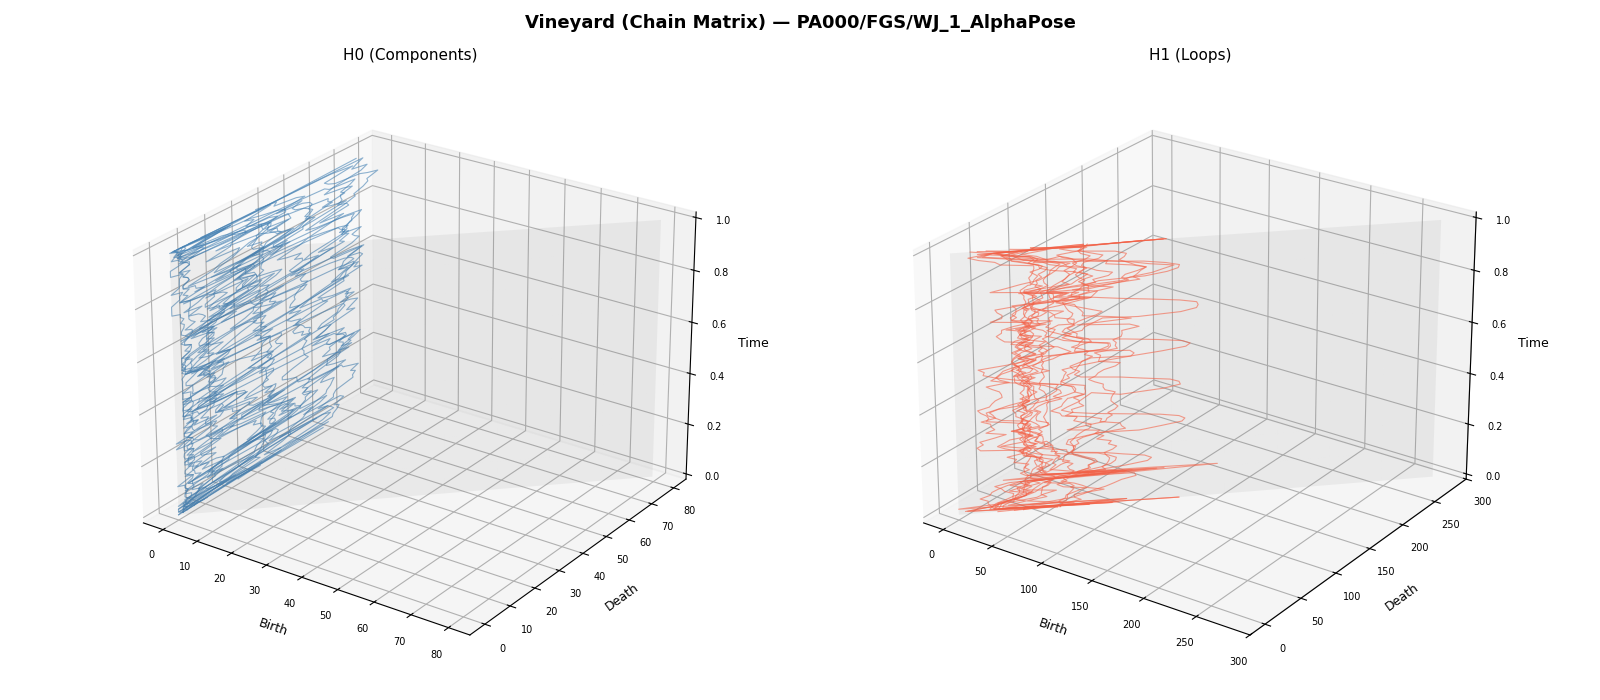

  Done: PA000/FGS/WJ_1_AlphaPose
  Processing 90 frames for PA000/FGS/WJ_2_AlphaPose...
    Complex: 17 vertices, 833 simplices, 90 frames
    H0 vines: 16, H1 vines: 120


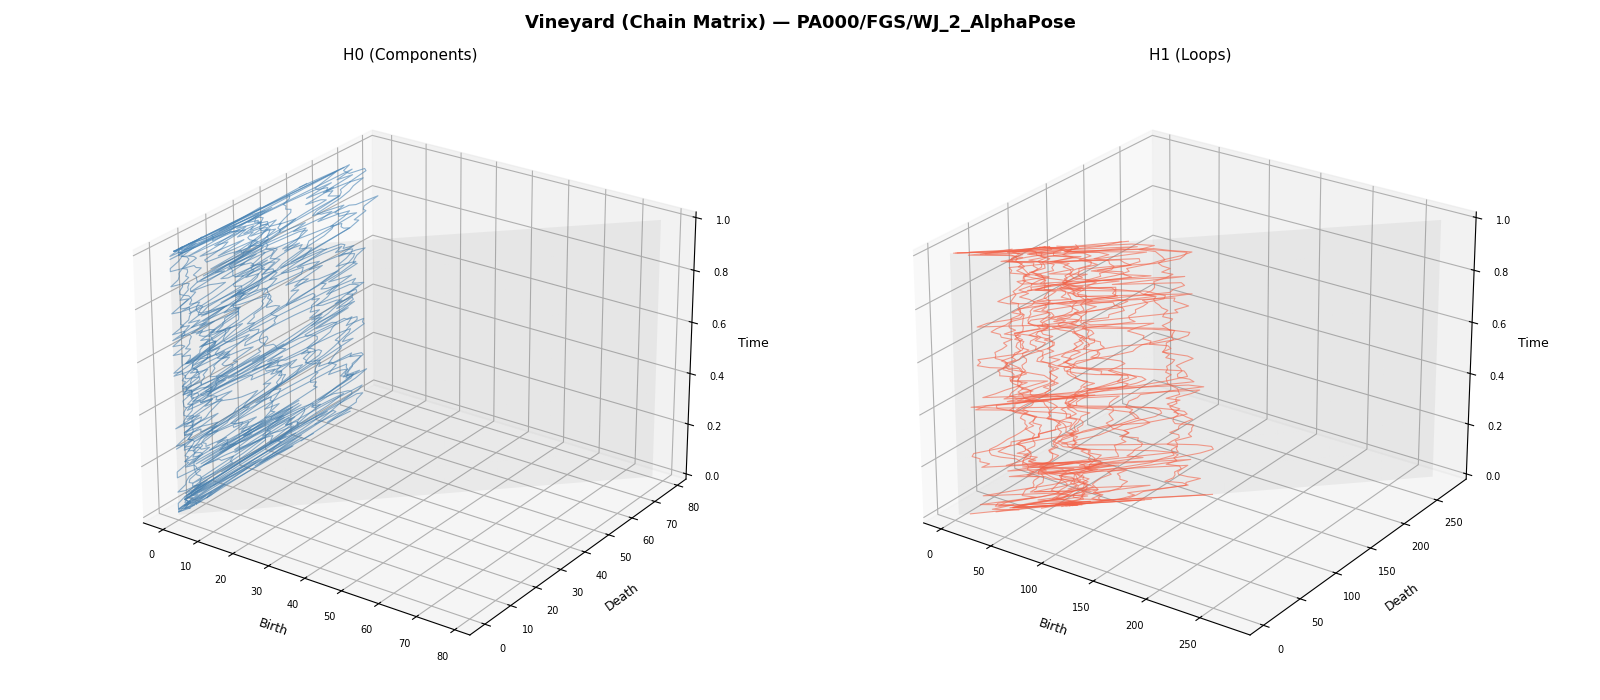

  Done: PA000/FGS/WJ_2_AlphaPose


In [49]:
for patient_dir in sorted(POSE_DIR.iterdir()):
    if not patient_dir.is_dir():
        continue
    for json_path in sorted(patient_dir.rglob("*_AlphaPose.json"))[:2]:
        visualize_pose_vineyard(json_path)
        # break

## Chaotic pendulum

In [74]:
"""
Chaos Pendulum - Fast Analytical Simulation
=============================================
Pivoting bar + two triple pendulums.
Uses explicit Lagrangian with analytical derivatives via a simplified
energy-based approach with numerical mass matrix (computed efficiently).
"""

import numpy as np
from scipy.integrate import solve_ivp
import csv
import os

# ─── Parameters ───
g = 9.81
L_bar = 2.0       # half-length
M_bar = 2.0
I_bar = (1/3) * M_bar * (2*L_bar)**2

L1, L2, L3 = 1.0, 1.0, 1.0
m1, m2, m3 = 1.0, 1.5, 0.8
damping = 0.05

T_total = 30.0
dt = 0.01
t_eval = np.arange(0, T_total, dt)

# Initial conditions
y0 = np.array([
    0.0, 0.15, 0.0, -0.1, -0.1, 0.05, 0.0,  # angles
    6.5, 4.0, 5.0, -7.0, -3.0, 8.0, 7.0,       # angular velocities
])

def compute_pos(q):
    """Compute positions of 6 mass points + bar endpoints. Returns (8,2)."""
    phi, th1L, th2L, th3L, th1R, th2R, th3R = q
    
    cp, sp = np.cos(phi), np.sin(phi)
    
    # Bar endpoints
    xbL, ybL = -L_bar * cp, -L_bar * sp
    xbR, ybR =  L_bar * cp,  L_bar * sp
    
    # Left chain
    s1L, c1L = np.sin(th1L), np.cos(th1L)
    s2L, c2L = np.sin(th2L), np.cos(th2L)
    s3L, c3L = np.sin(th3L), np.cos(th3L)
    
    x1L = xbL + L1*s1L;  y1L = ybL - L1*c1L
    x2L = x1L + L2*s2L;  y2L = y1L - L2*c2L
    x3L = x2L + L3*s3L;  y3L = y2L - L3*c3L
    
    # Right chain
    s1R, c1R = np.sin(th1R), np.cos(th1R)
    s2R, c2R = np.sin(th2R), np.cos(th2R)
    s3R, c3R = np.sin(th3R), np.cos(th3R)
    
    x1R = xbR + L1*s1R;  y1R = ybR - L1*c1R
    x2R = x1R + L2*s2R;  y2R = y1R - L2*c2R
    x3R = x2R + L3*s3R;  y3R = y2R - L3*c3R
    
    return np.array([
        [xbL, ybL], [xbR, ybR],
        [x1L, y1L], [x2L, y2L], [x3L, y3L],
        [x1R, y1R], [x2R, y2R], [x3R, y3R],
    ])


def compute_jacobian(q):
    """
    Analytical Jacobian: d(mass_positions)/d(q).
    Returns J of shape (6, 2, 7) for 6 mass points.
    """
    phi, th1L, th2L, th3L, th1R, th2R, th3R = q
    cp, sp = np.cos(phi), np.sin(phi)
    s1L, c1L = np.sin(th1L), np.cos(th1L)
    s2L, c2L = np.sin(th2L), np.cos(th2L)
    s3L, c3L = np.sin(th3L), np.cos(th3L)
    s1R, c1R = np.sin(th1R), np.cos(th1R)
    s2R, c2R = np.sin(th2R), np.cos(th2R)
    s3R, c3R = np.sin(th3R), np.cos(th3R)
    
    J = np.zeros((6, 2, 7))
    
    # Mass 0: ball1L at (xbL + L1*s1L, ybL - L1*c1L)
    # xbL = -L_bar*cp, ybL = -L_bar*sp
    # dx/dphi = L_bar*sp,  dy/dphi = -L_bar*cp
    # dx/dth1L = L1*c1L,   dy/dth1L = L1*s1L
    J[0, 0, 0] = L_bar*sp;    J[0, 1, 0] = -L_bar*cp
    J[0, 0, 1] = L1*c1L;      J[0, 1, 1] = L1*s1L
    
    # Mass 1: ball2L at (xbL + L1*s1L + L2*s2L, ybL - L1*c1L - L2*c2L)
    J[1, 0, 0] = L_bar*sp;    J[1, 1, 0] = -L_bar*cp
    J[1, 0, 1] = L1*c1L;      J[1, 1, 1] = L1*s1L
    J[1, 0, 2] = L2*c2L;      J[1, 1, 2] = L2*s2L
    
    # Mass 2: ball3L
    J[2, 0, 0] = L_bar*sp;    J[2, 1, 0] = -L_bar*cp
    J[2, 0, 1] = L1*c1L;      J[2, 1, 1] = L1*s1L
    J[2, 0, 2] = L2*c2L;      J[2, 1, 2] = L2*s2L
    J[2, 0, 3] = L3*c3L;      J[2, 1, 3] = L3*s3L
    
    # Mass 3: ball1R at (xbR + L1*s1R, ybR - L1*c1R)
    # xbR = L_bar*cp, ybR = L_bar*sp
    # dx/dphi = -L_bar*sp,  dy/dphi = L_bar*cp
    J[3, 0, 0] = -L_bar*sp;   J[3, 1, 0] = L_bar*cp
    J[3, 0, 4] = L1*c1R;      J[3, 1, 4] = L1*s1R
    
    # Mass 4: ball2R
    J[4, 0, 0] = -L_bar*sp;   J[4, 1, 0] = L_bar*cp
    J[4, 0, 4] = L1*c1R;      J[4, 1, 4] = L1*s1R
    J[4, 0, 5] = L2*c2R;      J[4, 1, 5] = L2*s2R
    
    # Mass 5: ball3R
    J[5, 0, 0] = -L_bar*sp;   J[5, 1, 0] = L_bar*cp
    J[5, 0, 4] = L1*c1R;      J[5, 1, 4] = L1*s1R
    J[5, 0, 5] = L2*c2R;      J[5, 1, 5] = L2*s2R
    J[5, 0, 6] = L3*c3R;      J[5, 1, 6] = L3*s3R
    
    return J


def compute_jacobian_dot(q, dq):
    """
    Time derivative of Jacobian: dJ/dt = sum_k (dJ/dq_k) * dq_k.
    Returns Jdot of shape (6, 2, 7).
    """
    phi, th1L, th2L, th3L, th1R, th2R, th3R = q
    dphi, dth1L, dth2L, dth3L, dth1R, dth2R, dth3R = dq
    
    cp, sp = np.cos(phi), np.sin(phi)
    s1L, c1L = np.sin(th1L), np.cos(th1L)
    s2L, c2L = np.sin(th2L), np.cos(th2L)
    s3L, c3L = np.sin(th3L), np.cos(th3L)
    s1R, c1R = np.sin(th1R), np.cos(th1R)
    s2R, c2R = np.sin(th2R), np.cos(th2R)
    s3R, c3R = np.sin(th3R), np.cos(th3R)
    
    Jd = np.zeros((6, 2, 7))
    
    # d/dt of J entries: chain rule on trig functions
    # For bar terms: d/dt(L_bar*sp) = L_bar*cp*dphi, d/dt(-L_bar*cp) = L_bar*sp*dphi
    
    # Mass 0 (ball1L)
    Jd[0, 0, 0] = L_bar*cp*dphi;     Jd[0, 1, 0] = L_bar*sp*dphi
    Jd[0, 0, 1] = -L1*s1L*dth1L;     Jd[0, 1, 1] = L1*c1L*dth1L
    
    # Mass 1 (ball2L)
    Jd[1, 0, 0] = L_bar*cp*dphi;     Jd[1, 1, 0] = L_bar*sp*dphi
    Jd[1, 0, 1] = -L1*s1L*dth1L;     Jd[1, 1, 1] = L1*c1L*dth1L
    Jd[1, 0, 2] = -L2*s2L*dth2L;     Jd[1, 1, 2] = L2*c2L*dth2L
    
    # Mass 2 (ball3L)
    Jd[2, 0, 0] = L_bar*cp*dphi;     Jd[2, 1, 0] = L_bar*sp*dphi
    Jd[2, 0, 1] = -L1*s1L*dth1L;     Jd[2, 1, 1] = L1*c1L*dth1L
    Jd[2, 0, 2] = -L2*s2L*dth2L;     Jd[2, 1, 2] = L2*c2L*dth2L
    Jd[2, 0, 3] = -L3*s3L*dth3L;     Jd[2, 1, 3] = L3*c3L*dth3L
    
    # Mass 3 (ball1R)
    Jd[3, 0, 0] = -L_bar*cp*dphi;    Jd[3, 1, 0] = -L_bar*sp*dphi
    Jd[3, 0, 4] = -L1*s1R*dth1R;     Jd[3, 1, 4] = L1*c1R*dth1R
    
    # Mass 4 (ball2R)
    Jd[4, 0, 0] = -L_bar*cp*dphi;    Jd[4, 1, 0] = -L_bar*sp*dphi
    Jd[4, 0, 4] = -L1*s1R*dth1R;     Jd[4, 1, 4] = L1*c1R*dth1R
    Jd[4, 0, 5] = -L2*s2R*dth2R;     Jd[4, 1, 5] = L2*c2R*dth2R
    
    # Mass 5 (ball3R)
    Jd[5, 0, 0] = -L_bar*cp*dphi;    Jd[5, 1, 0] = -L_bar*sp*dphi
    Jd[5, 0, 4] = -L1*s1R*dth1R;     Jd[5, 1, 4] = L1*c1R*dth1R
    Jd[5, 0, 5] = -L2*s2R*dth2R;     Jd[5, 1, 5] = L2*c2R*dth2R
    Jd[5, 0, 6] = -L3*s3R*dth3R;     Jd[5, 1, 6] = L3*c3R*dth3R
    
    return Jd


masses = np.array([m1, m2, m3, m1, m2, m3])
gvec = np.array([0, -g])  # gravity vector (y points up in math, down in display... let's be consistent)
# Actually in our coords, y is "up" in the math sense but we draw it inverted.
# Gravity pulls things in -y direction.
# The potential energy gradient for mass i: dV/dq_j = m_i * g * dyi/dq_j
# Force = -dV/dq = -m_i * g * (dy_i/dq_j) ... but gravity is in -y direction
# So gravitational generalized force Q_j = sum_i m_i * (-g) * J_i[1, j]
# Wait: F_grav on mass i = [0, -m_i*g]. Generalized force = J_i^T @ F_i
# Q = sum_i J_i^T @ [0, -m_i*g]

def derivs(t, y):
    n = 7
    q = y[:n]
    dq = y[n:]
    
    J = compute_jacobian(q)      # (6, 2, 7)
    Jd = compute_jacobian_dot(q, dq)  # (6, 2, 7)
    
    # Mass matrix: M = I_bar*e0e0^T + sum_i m_i * J_i^T @ J_i
    M = np.zeros((n, n))
    M[0, 0] = I_bar
    for i in range(6):
        Ji = J[i]  # (2, 7)
        M += masses[i] * (Ji.T @ Ji)
    
    # Gravitational generalized forces
    Q_grav = np.zeros(n)
    for i in range(6):
        Ji = J[i]  # (2, 7)
        F_i = np.array([0.0, -masses[i] * g])
        Q_grav += Ji.T @ F_i
    
    # Coriolis/centrifugal: C*dq where the full eq is M*ddq + C*dq = Q
    # C*dq = sum_i m_i * J_i^T @ Jd_i @ dq
    Cdq = np.zeros(n)
    for i in range(6):
        Ji = J[i]
        Jdi = Jd[i]
        vel_i = Jdi @ dq  # (2,) = centripetal acceleration contribution
        Cdq += masses[i] * (Ji.T @ vel_i)
    
    # M*ddq = Q_grav - Cdq - damping*dq
    rhs = Q_grav - Cdq - damping * dq
    ddq = np.linalg.solve(M, rhs)
    
    return np.concatenate([dq, ddq])


print("Running simulation...")
sol = solve_ivp(derivs, [0, T_total], y0, t_eval=t_eval,
                method='RK45', rtol=1e-8, atol=1e-10, max_step=0.005)

print(f"Integration complete: {sol.t.shape[0]} time steps, success={sol.success}")

# ─── Compute Point Cloud ───
n_steps = sol.t.shape[0]
point_cloud = np.zeros((n_steps, 7, 2))  # pivot + 6 balls
bar_endpoints = np.zeros((n_steps, 2, 2))

for i in range(n_steps):
    q = sol.y[:7, i]
    p = compute_pos(q)
    # p: 0=barL, 1=barR, 2=b1L, 3=b2L, 4=b3L, 5=b1R, 6=b2R, 7=b3R
    point_cloud[i, 0] = [0.0, 0.0]  # pivot
    point_cloud[i, 1] = p[2]  # ball1L
    point_cloud[i, 2] = p[3]  # ball2L
    point_cloud[i, 3] = p[4]  # ball3L
    point_cloud[i, 4] = p[5]  # ball1R
    point_cloud[i, 5] = p[6]  # ball2R
    point_cloud[i, 6] = p[7]  # ball3R
    bar_endpoints[i, 0] = p[0]  # barL
    bar_endpoints[i, 1] = p[1]  # barR

# ─── Save CSV ───
output_dir = "./"
csv_path = os.path.join(output_dir, "chaos_pendulum_pointcloud.csv")

with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'time',
        'pivot_x', 'pivot_y',
        'ball1L_x', 'ball1L_y', 'ball2L_x', 'ball2L_y', 'ball3L_x', 'ball3L_y',
        'ball1R_x', 'ball1R_y', 'ball2R_x', 'ball2R_y', 'ball3R_x', 'ball3R_y',
        'barL_x', 'barL_y', 'barR_x', 'barR_y',
    ])
    for i in range(n_steps):
        row = [f"{sol.t[i]:.4f}"]
        for j in range(7):
            row.extend([f"{point_cloud[i,j,0]:.6f}", f"{point_cloud[i,j,1]:.6f}"])
        row.extend([
            f"{bar_endpoints[i,0,0]:.6f}", f"{bar_endpoints[i,0,1]:.6f}",
            f"{bar_endpoints[i,1,0]:.6f}", f"{bar_endpoints[i,1,1]:.6f}",
        ])
        writer.writerow(row)

print(f"CSV saved: {csv_path} ({n_steps} rows)")

# Save numpy arrays
np.save(os.path.join(output_dir, "chaos_pendulum_pointcloud.npy"), point_cloud)
np.save(os.path.join(output_dir, "chaos_pendulum_times.npy"), sol.t)
np.save(os.path.join(output_dir, "chaos_pendulum_bar.npy"), bar_endpoints)
print("NumPy arrays saved.")
print(f"Point cloud shape: {point_cloud.shape}  (timesteps, points, xy)")

Running simulation...
Integration complete: 3000 time steps, success=True
CSV saved: ./chaos_pendulum_pointcloud.csv (3000 rows)
NumPy arrays saved.
Point cloud shape: (3000, 7, 2)  (timesteps, points, xy)


In [75]:
"""
Generate video of the chaos pendulum simulation.

Outputs:
  - MP4 if FFmpeg is installed
  - GIF fallback via Pillow (no external dependencies needed)

Usage: python render_video.py
  Expects .npy files in the same directory as this script.
"""

import os
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ─── Load data (same directory as script) ───
script_dir = "./"
point_cloud = np.load(os.path.join(script_dir, "chaos_pendulum_pointcloud.npy"))
times = np.load(os.path.join(script_dir, "chaos_pendulum_times.npy"))
bar_ep = np.load(os.path.join(script_dir, "chaos_pendulum_bar.npy"))

n_steps = point_cloud.shape[0]

# ─── Setup Figure ───
fig, ax = plt.subplots(figsize=(12, 10), facecolor='#0d1117')
ax.set_facecolor('#0d1117')
ax.set_xlim(-6, 6)
ax.set_ylim(-7, 3)
ax.set_aspect('equal')
ax.grid(True, alpha=0.1, color='#30363d')
ax.set_xlabel('x (m)', color='#8b949e', fontsize=11)
ax.set_ylabel('y (m)', color='#8b949e', fontsize=11)
ax.tick_params(colors='#484f58')
for spine in ax.spines.values():
    spine.set_color('#21262d')

title_text = ax.set_title('Chaos Pendulum — t = 0.00 s', color='#e6edf3',
                           fontsize=15, fontweight='bold', pad=15)

# Colors
cL = ['#f97583', '#f97583', '#f97583']  # left chain (red tones)
cR = ['#79c0ff', '#79c0ff', '#79c0ff']  # right chain (blue tones)
ball_sz = [8, 11, 7]

# Trail data
trail_len = 200
trails = {i: ([], []) for i in range(6)}  # 6 balls

# Plot elements
bar_line, = ax.plot([], [], '-', color='#c9d1d9', linewidth=3.5, solid_capstyle='round', zorder=5)
pivot_dot, = ax.plot([], [], 'o', color='#f0c000', markersize=14, zorder=10,
                      markeredgecolor='#b08800', markeredgewidth=1.5)

arm_lines = []
ball_dots = []
trail_lines = []

for j in range(3):
    arm_lines.append(ax.plot([], [], '-', color=cL[j], linewidth=2, alpha=0.7, zorder=3)[0])
    ball_dots.append(ax.plot([], [], 'o', color=cL[j], markersize=ball_sz[j],
                              markeredgecolor='white', markeredgewidth=0.5, zorder=8)[0])
    trail_lines.append(ax.plot([], [], '-', color=cL[j], linewidth=0.8, alpha=0.35, zorder=1)[0])

for j in range(3):
    arm_lines.append(ax.plot([], [], '-', color=cR[j], linewidth=2, alpha=0.7, zorder=3)[0])
    ball_dots.append(ax.plot([], [], 'o', color=cR[j], markersize=ball_sz[j],
                              markeredgecolor='white', markeredgewidth=0.5, zorder=8)[0])
    trail_lines.append(ax.plot([], [], '-', color=cR[j], linewidth=0.8, alpha=0.35, zorder=1)[0])

# Labels
ax.text(0.02, 0.98, 'Pivoting bar + 2x triple pendulum\n7 DOF chaotic system',
        transform=ax.transAxes, color='#8b949e', fontsize=9, va='top',
        fontfamily='monospace', alpha=0.7)

# Subsample: render every 3rd frame -> ~33 fps from 100Hz data
step = 3
frame_indices = list(range(0, n_steps, step))
n_frames = len(frame_indices)
print(f"Rendering {n_frames} frames...")


def update(frame_num):
    i = frame_indices[frame_num]
    t = times[i]
    title_text.set_text(f'Chaos Pendulum — t = {t:.2f} s')

    bL = bar_ep[i, 0]
    bR = bar_ep[i, 1]
    bar_line.set_data([bL[0], bR[0]], [bL[1], bR[1]])
    pivot_dot.set_data([0], [0])

    # Left chain: bar_left -> b1L -> b2L -> b3L
    anchors_L = [bL, point_cloud[i, 1], point_cloud[i, 2], point_cloud[i, 3]]
    for j in range(3):
        p0, p1 = anchors_L[j], anchors_L[j + 1]
        arm_lines[j].set_data([p0[0], p1[0]], [p0[1], p1[1]])
        ball_dots[j].set_data([p1[0]], [p1[1]])
        trails[j][0].append(p1[0]); trails[j][1].append(p1[1])
        if len(trails[j][0]) > trail_len:
            trails[j] = (trails[j][0][-trail_len:], trails[j][1][-trail_len:])
        trail_lines[j].set_data(trails[j][0], trails[j][1])

    # Right chain: bar_right -> b1R -> b2R -> b3R
    anchors_R = [bR, point_cloud[i, 4], point_cloud[i, 5], point_cloud[i, 6]]
    for j in range(3):
        p0, p1 = anchors_R[j], anchors_R[j + 1]
        arm_lines[3 + j].set_data([p0[0], p1[0]], [p0[1], p1[1]])
        ball_dots[3 + j].set_data([p1[0]], [p1[1]])
        trails[3 + j][0].append(p1[0]); trails[3 + j][1].append(p1[1])
        if len(trails[3 + j][0]) > trail_len:
            trails[3 + j] = (trails[3 + j][0][-trail_len:], trails[3 + j][1][-trail_len:])
        trail_lines[3 + j].set_data(trails[3 + j][0], trails[3 + j][1])

    return []


anim = FuncAnimation(fig, update, frames=n_frames, interval=30, blit=True)

# ─── Save: try MP4 (FFmpeg) first, fall back to GIF (Pillow) ───
try:
    from matplotlib.animation import FFMpegWriter
    video_path = os.path.join(script_dir, "chaos_pendulum.mp4")
    writer = FFMpegWriter(fps=33, metadata=dict(title='Chaos Pendulum'), bitrate=4000)
    anim.save(video_path, writer=writer, dpi=100)
    print(f"MP4 saved: {video_path}")
except (FileNotFoundError, RuntimeError) as e:
    print(f"FFmpeg not available ({e}), falling back to GIF via Pillow...")
    from matplotlib.animation import PillowWriter
    video_path = os.path.join(script_dir, "chaos_pendulum.gif")
    writer = PillowWriter(fps=33)
    anim.save(video_path, writer=writer, dpi=80)
    print(f"GIF saved: {video_path}")

plt.close()
print("Done!")

Rendering 1000 frames...
MP4 saved: ./chaos_pendulum.mp4
Done!


### Chaos Pendulum — Vineyard (Rips Complex, Chain Matrix)

In [ ]:
%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
import sys
from pathlib import Path

sys.path.insert(0, str(Path(".").resolve()))
import vineyard_ext

# ─── Load CSV ───
df = pd.read_csv("chaos_pendulum_pointcloud.csv")
print(f"Loaded {len(df)} rows")

# 8 tracked points (no pivot — it's fixed at origin):
# ball1L, ball2L, ball3L, ball1R, ball2R, ball3R, barL, barR
point_cols = [
    ("ball1L_x", "ball1L_y"), ("ball2L_x", "ball2L_y"), ("ball3L_x", "ball3L_y"),
    ("ball1R_x", "ball1R_y"), ("ball2R_x", "ball2R_y"), ("ball3R_x", "ball3R_y"),
    ("barL_x", "barL_y"), ("barR_x", "barR_y"),
]
N_PTS = len(point_cols)  # 8

n_total = len(df)
STEP = 10
frame_idx = list(range(0, n_total, STEP))
times = df["time"].values[frame_idx]
print(f"Using {len(frame_idx)} frames (every {STEP}th, dt={STEP*0.01:.2f}s)")

# Build point clouds
all_pts = np.zeros((len(frame_idx), N_PTS, 2))
for j, (cx, cy) in enumerate(point_cols):
    all_pts[:, j, 0] = df[cx].values[frame_idx]
    all_pts[:, j, 1] = df[cy].values[frame_idx]

# Distance matrices
all_dist = [squareform(pdist(pts)) for pts in all_pts]

# ─── Build union Rips complex ───
MAX_EDGE_LENGTH = 10.0  # meters

simplices = [[i] for i in range(N_PTS)]

# Union of edges across all frames
edge_set = set()
for D in all_dist:
    for i in range(N_PTS):
        for j in range(i + 1, N_PTS):
            if D[i, j] <= MAX_EDGE_LENGTH:
                edge_set.add((i, j))
edges = sorted(edge_set)
for i, j in edges:
    simplices.append([i, j])

# Triangles
edge_set_frozen = set(edges)
for i, j in edges:
    for k in range(j + 1, N_PTS):
        if (i, k) in edge_set_frozen and (j, k) in edge_set_frozen:
            simplices.append([i, j, k])

print(f"Rips complex: {N_PTS} vertices, {len(edges)} edges, "
      f"{len(simplices) - N_PTS - len(edges)} triangles, "
      f"{len(simplices)} total simplices")

# Rips filtration per frame
filtration_per_frame = []
for D in all_dist:
    filt = [0.0] * len(simplices)
    for idx, sx in enumerate(simplices):
        if len(sx) == 2:
            filt[idx] = D[sx[0], sx[1]]
        elif len(sx) == 3:
            filt[idx] = max(D[sx[0], sx[1]], D[sx[0], sx[2]], D[sx[1], sx[2]])
    filtration_per_frame.append(filt)

# ─── Compute vineyard ───
print("Computing vineyard via C++ chain matrix...")
barcodes = vineyard_ext.compute_vineyard(simplices, filtration_per_frame)
print(f"Got {len(barcodes)} frame barcodes, {len(barcodes[0])} bars each")

# ─── Extract vines ───
MIN_VINE_FRAMES = 5
n_bars = len(barcodes[0])
vines_h0, vines_h1 = [], []

for bar_idx in range(n_bars):
    vine = []
    dim = None
    for fi, bc in enumerate(barcodes):
        if bar_idx >= len(bc):
            continue
        d, b, dth = bc[bar_idx]
        dim = d
        if np.isinf(dth):
            continue
        vine.append((times[fi], b, dth))
    if len(vine) >= MIN_VINE_FRAMES and dim is not None:
        if dim == 0:
            vines_h0.append(vine)
        elif dim == 1:
            vines_h1.append(vine)

print(f"H0 vines: {len(vines_h0)}, H1 vines: {len(vines_h1)}")

# ─── Visualize ───
fig = plt.figure(figsize=(16, 7))
fig.suptitle("Rips Vineyard — Chaos Pendulum (8 points, no pivot)", fontsize=13, fontweight="bold")

for subplot_idx, (dim_label, vines, color) in enumerate([
    ("H0 (Components)", vines_h0, "steelblue"),
    ("H1 (Loops)", vines_h1, "tomato"),
]):
    ax = fig.add_subplot(1, 2, subplot_idx + 1, projection="3d")

    for vine in vines:
        vine_sorted = sorted(vine, key=lambda x: x[0])
        t_vals = [v[0] for v in vine_sorted]
        births = [v[1] for v in vine_sorted]
        deaths = [v[2] for v in vine_sorted]
        ax.plot(births, deaths, t_vals, color=color, alpha=0.6, linewidth=0.8)

    # Diagonal plane
    all_vals = []
    for vine in vines:
        for _, b, d in vine:
            all_vals.extend([b, d])
    if all_vals:
        vmin, vmax = min(all_vals), max(all_vals)
        grid = np.linspace(vmin, vmax, 10)
        B, T = np.meshgrid(grid, np.linspace(times[0], times[-1], 10))
        ax.plot_surface(B, B, T, alpha=0.07, color="gray")

    ax.set_xlabel("Birth", fontsize=9, labelpad=6)
    ax.set_ylabel("Death", fontsize=9, labelpad=6)
    ax.set_zlabel("Time (s)", fontsize=9, labelpad=6)
    ax.set_title(dim_label, fontsize=11)
    ax.tick_params(labelsize=7)
    ax.view_init(elev=25, azim=-55)

plt.tight_layout()
plt.show()

## 3 rod chaos pendulum

In [1]:
"""
3-Rod Star Chaos Pendulum Simulation
======================================
System:
  - Central pivot (free to rotate)
  - 3 rigid rods at FIXED angles relative to each other
  - Each rod tip has a 2-ball pendulum chain
  
Generalized coordinates (7 DOF):
  alpha          = rotation angle of the entire star
  th1_a, th2_a   = pendulum angles for rod A chain
  th1_b, th2_b   = pendulum angles for rod B chain  
  th1_c, th2_c   = pendulum angles for rod C chain

Output:
  - CSV point cloud (10 points per timestep)
  - NumPy arrays
"""

import numpy as np
from scipy.integrate import solve_ivp
import csv
import os

# ─── Physical Parameters ───
g = 9.81

# Star body
M_star = 3.0
rod_lengths = [1.8, 1.8, 1.8]

# Fixed angles in BODY frame (Y-shape from the image)
rod_body_angles = [
    np.radians(120),   # Rod A: upper-left
    np.radians(0),     # Rod B: right  
    np.radians(230),   # Rod C: lower-left
]

I_star = sum((1/3) * (M_star/3) * L**2 for L in rod_lengths)

# Pendulum parameters
L1, L2 = 0.4, 0.4
m1, m2 = 1.0, 0.7
damping = 0.03

# Simulation
T_total = 30.0
dt = 0.01
t_eval = np.arange(0, T_total, dt)
N_DOF = 7

y0 = np.array([
    0.0,                # alpha
    0.25, 0.35,           # rod A pendulum
   -0.35, 0.40,         # rod B pendulum
    0.21, -0.71,          # rod C pendulum
    3.0,                # d_alpha (impulse)
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
])


def compute_all_positions(q):
    alpha = q[0]
    pend = q[1:]
    pivot = np.array([0.0, 0.0])
    tips, balls = [], []
    for i in range(3):
        ang = alpha + rod_body_angles[i]
        tip = pivot + rod_lengths[i] * np.array([np.cos(ang), np.sin(ang)])
        tips.append(tip)
        th1, th2 = pend[2*i], pend[2*i+1]
        b1 = tip + L1 * np.array([np.sin(th1), -np.cos(th1)])
        b2 = b1  + L2 * np.array([np.sin(th2), -np.cos(th2)])
        balls.extend([b1, b2])
    return pivot, tips, balls


def compute_jacobians(q, dq):
    alpha, dalpha = q[0], dq[0]
    pend, dpend = q[1:], dq[1:]
    J  = np.zeros((6, 2, N_DOF))
    Jd = np.zeros((6, 2, N_DOF))

    for i in range(3):
        ang = alpha + rod_body_angles[i]
        cr, sr = np.cos(ang), np.sin(ang)
        Lr = rod_lengths[i]
        th1, th2 = pend[2*i], pend[2*i+1]
        dth1, dth2 = dpend[2*i], dpend[2*i+1]
        s1, c1 = np.sin(th1), np.cos(th1)
        s2, c2 = np.sin(th2), np.cos(th2)
        j1, j2, bi = 1+2*i, 2+2*i, 2*i

        # Ball 1
        J[bi,0,0] = -Lr*sr;      J[bi,1,0] = Lr*cr
        J[bi,0,j1] = L1*c1;      J[bi,1,j1] = L1*s1
        Jd[bi,0,0] = -Lr*cr*dalpha;  Jd[bi,1,0] = -Lr*sr*dalpha
        Jd[bi,0,j1] = -L1*s1*dth1;   Jd[bi,1,j1] = L1*c1*dth1

        # Ball 2
        J[bi+1,0,0] = -Lr*sr;    J[bi+1,1,0] = Lr*cr
        J[bi+1,0,j1] = L1*c1;    J[bi+1,1,j1] = L1*s1
        J[bi+1,0,j2] = L2*c2;    J[bi+1,1,j2] = L2*s2
        Jd[bi+1,0,0] = -Lr*cr*dalpha;   Jd[bi+1,1,0] = -Lr*sr*dalpha
        Jd[bi+1,0,j1] = -L1*s1*dth1;    Jd[bi+1,1,j1] = L1*c1*dth1
        Jd[bi+1,0,j2] = -L2*s2*dth2;    Jd[bi+1,1,j2] = L2*c2*dth2

    return J, Jd


masses_vec = np.array([m1, m2, m1, m2, m1, m2])


def derivs(t, y):
    q, dq = y[:N_DOF], y[N_DOF:]
    J, Jd = compute_jacobians(q, dq)

    M = np.zeros((N_DOF, N_DOF))
    M[0, 0] = I_star
    Q_grav = np.zeros(N_DOF)
    Cdq = np.zeros(N_DOF)

    for i in range(6):
        Ji, Jdi = J[i], Jd[i]
        mi = masses_vec[i]
        M += mi * (Ji.T @ Ji)
        Q_grav += Ji.T @ np.array([0.0, -mi * g])
        Cdq += mi * (Ji.T @ (Jdi @ dq))

    ddq = np.linalg.solve(M, Q_grav - Cdq - damping * dq)
    return np.concatenate([dq, ddq])


print("Running 3-rod star chaos pendulum simulation...")
sol = solve_ivp(derivs, [0, T_total], y0, t_eval=t_eval,
                method='RK45', rtol=1e-8, atol=1e-10, max_step=0.005)
print(f"Done: {sol.t.shape[0]} steps, success={sol.success}")

# ─── Point Cloud ───
n_steps = sol.t.shape[0]
all_pos = np.zeros((n_steps, 10, 2))
for i in range(n_steps):
    piv, tips, balls = compute_all_positions(sol.y[:N_DOF, i])
    all_pos[i, 0] = piv
    for j in range(3): all_pos[i, 1+j] = tips[j]
    for j in range(6): all_pos[i, 4+j] = balls[j]

# ─── Save ───
output_dir = "./"

csv_path = os.path.join(output_dir, "star_pendulum_pointcloud.csv")
with open(csv_path, 'w', newline='') as f:
    w = csv.writer(f)
    labels = ['pivot','tipA','tipB','tipC','ball1A','ball2A','ball1B','ball2B','ball1C','ball2C']
    w.writerow(['time'] + [f'{l}_{c}' for l in labels for c in ('x','y')])
    for i in range(n_steps):
        row = [f"{sol.t[i]:.4f}"]
        for j in range(10):
            row.extend([f"{all_pos[i,j,0]:.6f}", f"{all_pos[i,j,1]:.6f}"])
        w.writerow(row)

np.save(os.path.join(output_dir, "star_pendulum_positions.npy"), all_pos)
np.save(os.path.join(output_dir, "star_pendulum_times.npy"), sol.t)

print(f"CSV: {csv_path} ({n_steps} rows, 10 points)")
print(f"NPY: positions {all_pos.shape}")

Running 3-rod star chaos pendulum simulation...
Done: 3000 steps, success=True
CSV: ./star_pendulum_pointcloud.csv (3000 rows, 10 points)
NPY: positions (3000, 10, 2)


In [2]:
"""
Render video for the 3-rod star chaos pendulum.
Tries MP4 (FFmpeg), falls back to GIF (Pillow).

Usage: python render_video.py
  Expects .npy files in the same directory.
"""

import os
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ─── Load ───
script_dir = "./"
pos = np.load(os.path.join(script_dir, "star_pendulum_positions.npy"))
times = np.load(os.path.join(script_dir, "star_pendulum_times.npy"))
n_steps = pos.shape[0]

# pos layout: 0=pivot, 1=tipA, 2=tipB, 3=tipC,
#             4=b1A, 5=b2A, 6=b1B, 7=b2B, 8=b1C, 9=b2C

# ─── Figure ───
fig, ax = plt.subplots(figsize=(11, 11), facecolor='#0d1117')
ax.set_facecolor('#0d1117')
ax.set_xlim(-5.5, 5.5)
ax.set_ylim(-6, 4)
ax.set_aspect('equal')
ax.grid(True, alpha=0.08, color='#30363d')
ax.set_xlabel('x (m)', color='#8b949e', fontsize=11)
ax.set_ylabel('y (m)', color='#8b949e', fontsize=11)
ax.tick_params(colors='#484f58')
for spine in ax.spines.values():
    spine.set_color('#21262d')

title = ax.set_title('3-Rod Star Pendulum - t = 0.00 s',
                      color='#e6edf3', fontsize=15, fontweight='bold', pad=15)

# ─── Colors per rod chain ───
rod_colors  = ['#f97583', '#79c0ff', '#7ee787']   # A=red, B=blue, C=green
ball_colors = ['#ff4d6a', '#4da6ff', '#56d364']
trail_colors = ['#f9758366', '#79c0ff66', '#7ee78766']

# Plot elements
rod_lines = [ax.plot([], [], '-', color=c, lw=2.5, solid_capstyle='round', zorder=5)[0]
             for c in rod_colors]
pivot_dot, = ax.plot([], [], 'o', color='#f0c000', ms=14, zorder=15,
                      mec='#b08800', mew=1.5)

# Pendulum arms and balls (2 per rod = 6 total)
arm_lines = []
ball_dots = []
trail_lines = []
trails = {}

for i in range(3):
    for j in range(2):
        idx = i*2 + j
        sz = 10 if j == 0 else 8
        arm_lines.append(ax.plot([], [], '-', color=rod_colors[i], lw=1.5, alpha=0.6, zorder=3)[0])
        ball_dots.append(ax.plot([], [], 'o', color=ball_colors[i], ms=sz,
                                  mec='white', mew=0.5, zorder=10)[0])
        trail_lines.append(ax.plot([], [], '-', color=rod_colors[i], lw=0.7, alpha=0.3, zorder=1)[0])
        trails[idx] = ([], [])

ax.text(0.02, 0.98, '3-rod star + 3x double pendulum\n7 DOF chaotic system',
        transform=ax.transAxes, color='#8b949e', fontsize=9, va='top',
        fontfamily='monospace', alpha=0.7)

# ─── Animation ───
trail_len = 200
step = 3
frame_indices = list(range(0, n_steps, step))
n_frames = len(frame_indices)
print(f"Rendering {n_frames} frames...")


def update(frame_num):
    fi = frame_indices[frame_num]
    t = times[fi]
    title.set_text(f'3-Rod Star Pendulum - t = {t:.2f} s')

    piv = pos[fi, 0]
    pivot_dot.set_data([piv[0]], [piv[1]])

    for i in range(3):
        tip = pos[fi, 1+i]
        # Rod line: pivot -> tip
        rod_lines[i].set_data([piv[0], tip[0]], [piv[1], tip[1]])

        # Pendulum chain: tip -> b1 -> b2
        b1 = pos[fi, 4 + 2*i]
        b2 = pos[fi, 5 + 2*i]
        anchors = [tip, b1, b2]

        for j in range(2):
            idx = i*2 + j
            p0, p1 = anchors[j], anchors[j+1]
            arm_lines[idx].set_data([p0[0], p1[0]], [p0[1], p1[1]])
            ball_dots[idx].set_data([p1[0]], [p1[1]])

            trails[idx][0].append(p1[0])
            trails[idx][1].append(p1[1])
            if len(trails[idx][0]) > trail_len:
                trails[idx] = (trails[idx][0][-trail_len:], trails[idx][1][-trail_len:])
            trail_lines[idx].set_data(trails[idx][0], trails[idx][1])

    return []


anim = FuncAnimation(fig, update, frames=n_frames, interval=30, blit=True)

# ─── Save ───
try:
    from matplotlib.animation import FFMpegWriter
    out = os.path.join(script_dir, "star_pendulum.mp4")
    writer = FFMpegWriter(fps=33, bitrate=4000)
    anim.save(out, writer=writer, dpi=100)
    print(f"MP4 saved: {out}")
except (FileNotFoundError, RuntimeError) as e:
    print(f"FFmpeg not available ({e}), falling back to GIF...")
    from matplotlib.animation import PillowWriter
    out = os.path.join(script_dir, "star_pendulum.gif")
    writer = PillowWriter(fps=33)
    anim.save(out, writer=writer, dpi=80)
    print(f"GIF saved: {out}")

plt.close()
print("Done!")

Rendering 1000 frames...
MP4 saved: ./star_pendulum.mp4
Done!


### Star Pendulum — Vineyard (Čech Complex, Chain Matrix)

Loaded 3000 rows
Using 15 frames (every 10th, dt=0.10s)
Čech complex: 9 vertices, 36 edges, 84 triangles, 129 total simplices
Computing Čech vineyard via C++ chain matrix...
Got 15 frame barcodes, 93 bars each
H0 vines: 8, H1 vines: 28


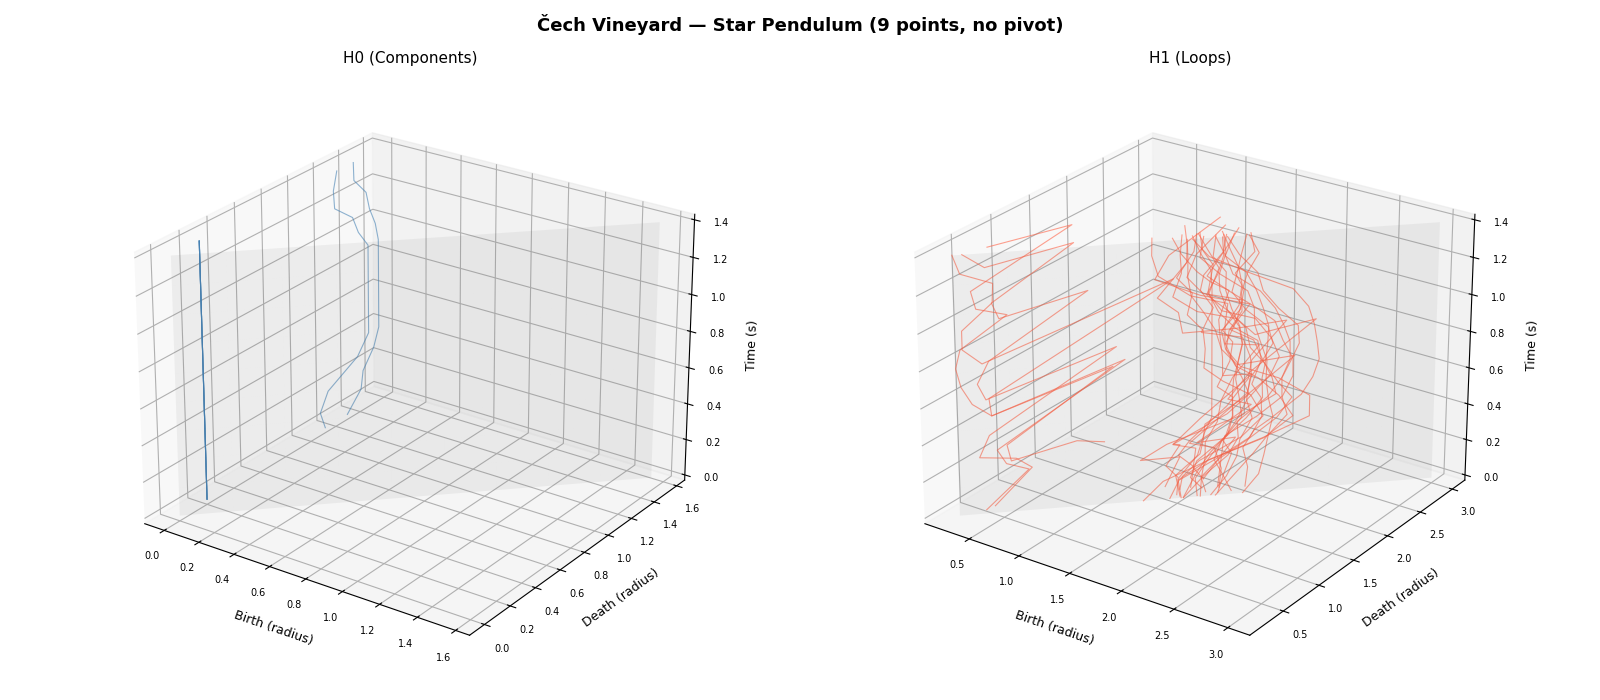

In [6]:
%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
import sys
from pathlib import Path

sys.path.insert(0, str(Path(".").resolve()))
import vineyard_ext

# ─── Load CSV ───
df = pd.read_csv("star_pendulum_pointcloud.csv")
print(f"Loaded {len(df)} rows")

# 9 tracked points (no pivot — it's fixed at origin):
# 3 star tips + 6 pendulum balls
point_cols = [
    ("tipA_x", "tipA_y"), ("tipB_x", "tipB_y"), ("tipC_x", "tipC_y"),
    ("ball1A_x", "ball1A_y"), ("ball2A_x", "ball2A_y"),
    ("ball1B_x", "ball1B_y"), ("ball2B_x", "ball2B_y"),
    ("ball1C_x", "ball1C_y"), ("ball2C_x", "ball2C_y"),
]
N_PTS = len(point_cols)  # 9

n_total = int(len(df)/20)
# n_total = len(df)
STEP = 10
frame_idx = list(range(0, n_total, STEP))
times = df["time"].values[frame_idx]
print(f"Using {len(frame_idx)} frames (every {STEP}th, dt={STEP*0.01:.2f}s)")

# Build point clouds
all_pts = np.zeros((len(frame_idx), N_PTS, 2))
for j, (cx, cy) in enumerate(point_cols):
    all_pts[:, j, 0] = df[cx].values[frame_idx]
    all_pts[:, j, 1] = df[cy].values[frame_idx]

# Distance matrices
all_dist = [squareform(pdist(pts)) for pts in all_pts]

# ─── Čech filtration helpers ───
MAX_RADIUS = 3.0  # clamp circumradius to avoid GUDHI vine_swap bug

def circumradius(p1, p2, p3):
    """Circumradius of triangle (p1, p2, p3)."""
    a = np.linalg.norm(p2 - p3)
    b = np.linalg.norm(p1 - p3)
    c = np.linalg.norm(p1 - p2)
    s = (a + b + c) / 2
    area = np.sqrt(max(s * (s - a) * (s - b) * (s - c), 0))
    if area < 1e-12:
        return max(a, b, c) / 2  # degenerate triangle
    return (a * b * c) / (4 * area)

# ─── Build union Čech complex ───
simplices = [[i] for i in range(N_PTS)]

# Union of edges across all frames (Čech edge filt = dist/2)
edge_set = set()
for D in all_dist:
    for i in range(N_PTS):
        for j in range(i + 1, N_PTS):
            if D[i, j] / 2 <= MAX_RADIUS:
                edge_set.add((i, j))
edges = sorted(edge_set)
for i, j in edges:
    simplices.append([i, j])

# Triangles: add [i,j,k] if all three edges exist in the union
edge_set_frozen = set(edges)
for i, j in edges:
    for k in range(j + 1, N_PTS):
        if (i, k) in edge_set_frozen and (j, k) in edge_set_frozen:
            simplices.append([i, j, k])

n_edges = len(edges)
n_tris = len(simplices) - N_PTS - n_edges
print(f"Čech complex: {N_PTS} vertices, {n_edges} edges, {n_tris} triangles, "
      f"{len(simplices)} total simplices")

# Čech filtration per frame:
#   vertex: 0
#   edge [i,j]: dist(i,j) / 2
#   triangle [i,j,k]: circumradius (clamped to MAX_RADIUS)
filtration_per_frame = []
for fi, D in enumerate(all_dist):
    pts = all_pts[fi]
    filt = [0.0] * len(simplices)
    for idx, sx in enumerate(simplices):
        if len(sx) == 2:
            filt[idx] = D[sx[0], sx[1]] / 2
        elif len(sx) == 3:
            max_edge_r = max(D[sx[0], sx[1]], D[sx[0], sx[2]], D[sx[1], sx[2]]) / 2
            cr = circumradius(pts[sx[0]], pts[sx[1]], pts[sx[2]])
            cr = max(cr, max_edge_r)  # must be >= all edge filtrations
            filt[idx] = min(cr, MAX_RADIUS)  # clamp to avoid vine_swap crash
    filtration_per_frame.append(filt)

# ─── Compute vineyard ───
print("Computing Čech vineyard via C++ chain matrix...")
barcodes = vineyard_ext.compute_vineyard(simplices, filtration_per_frame)
print(f"Got {len(barcodes)} frame barcodes, {len(barcodes[0])} bars each")

# ─── Extract vines ───
MIN_VINE_FRAMES = 5
n_bars = len(barcodes[0])
vines_h0, vines_h1 = [], []

for bar_idx in range(n_bars):
    vine = []
    dim = None
    for fi, bc in enumerate(barcodes):
        if bar_idx >= len(bc):
            continue
        d, b, dth = bc[bar_idx]
        dim = d
        if np.isinf(dth):
            continue
        vine.append((times[fi], b, dth))
    if len(vine) >= MIN_VINE_FRAMES and dim is not None:
        if dim == 0:
            vines_h0.append(vine)
        elif dim == 1:
            vines_h1.append(vine)

print(f"H0 vines: {len(vines_h0)}, H1 vines: {len(vines_h1)}")

# ─── Visualize ───
fig = plt.figure(figsize=(16, 7))
fig.suptitle("Čech Vineyard — Star Pendulum (9 points, no pivot)", fontsize=13, fontweight="bold")

for subplot_idx, (dim_label, vines, color) in enumerate([
    ("H0 (Components)", vines_h0, "steelblue"),
    ("H1 (Loops)", vines_h1, "tomato"),
]):
    ax = fig.add_subplot(1, 2, subplot_idx + 1, projection="3d")

    for vine in vines:
        vine_sorted = sorted(vine, key=lambda x: x[0])
        t_vals = [v[0] for v in vine_sorted]
        births = [v[1] for v in vine_sorted]
        deaths = [v[2] for v in vine_sorted]
        diff = [(deaths[i]-births[i]) for i in range(len(births))]
        if all(x == 0 for x in diff):
            continue
        ax.plot(births, deaths, t_vals, color=color, alpha=0.6, linewidth=0.8)

    all_vals = []
    for vine in vines:
        for _, b, d in vine:
            all_vals.extend([b, d])
    if all_vals:
        vmin, vmax = min(all_vals), max(all_vals)
        grid = np.linspace(vmin, vmax, 10)
        B, T = np.meshgrid(grid, np.linspace(times[0], times[-1], 10))
        ax.plot_surface(B, B, T, alpha=0.07, color="gray")

    ax.set_xlabel("Birth (radius)", fontsize=9, labelpad=6)
    ax.set_ylabel("Death (radius)", fontsize=9, labelpad=6)
    ax.set_zlabel("Time (s)", fontsize=9, labelpad=6)
    ax.set_title(dim_label, fontsize=11)
    ax.tick_params(labelsize=7)
    ax.view_init(elev=25, azim=-55)

plt.tight_layout()
plt.show()

### Why H1 features have near-zero persistence in the star pendulum

The "hole in the middle" that you see visually is **not captured** by the Rips
complex because there are too few points. This cell shows the exact moment an H1
feature is born (a cycle of edges closes) and when it dies (a triangle fills it).

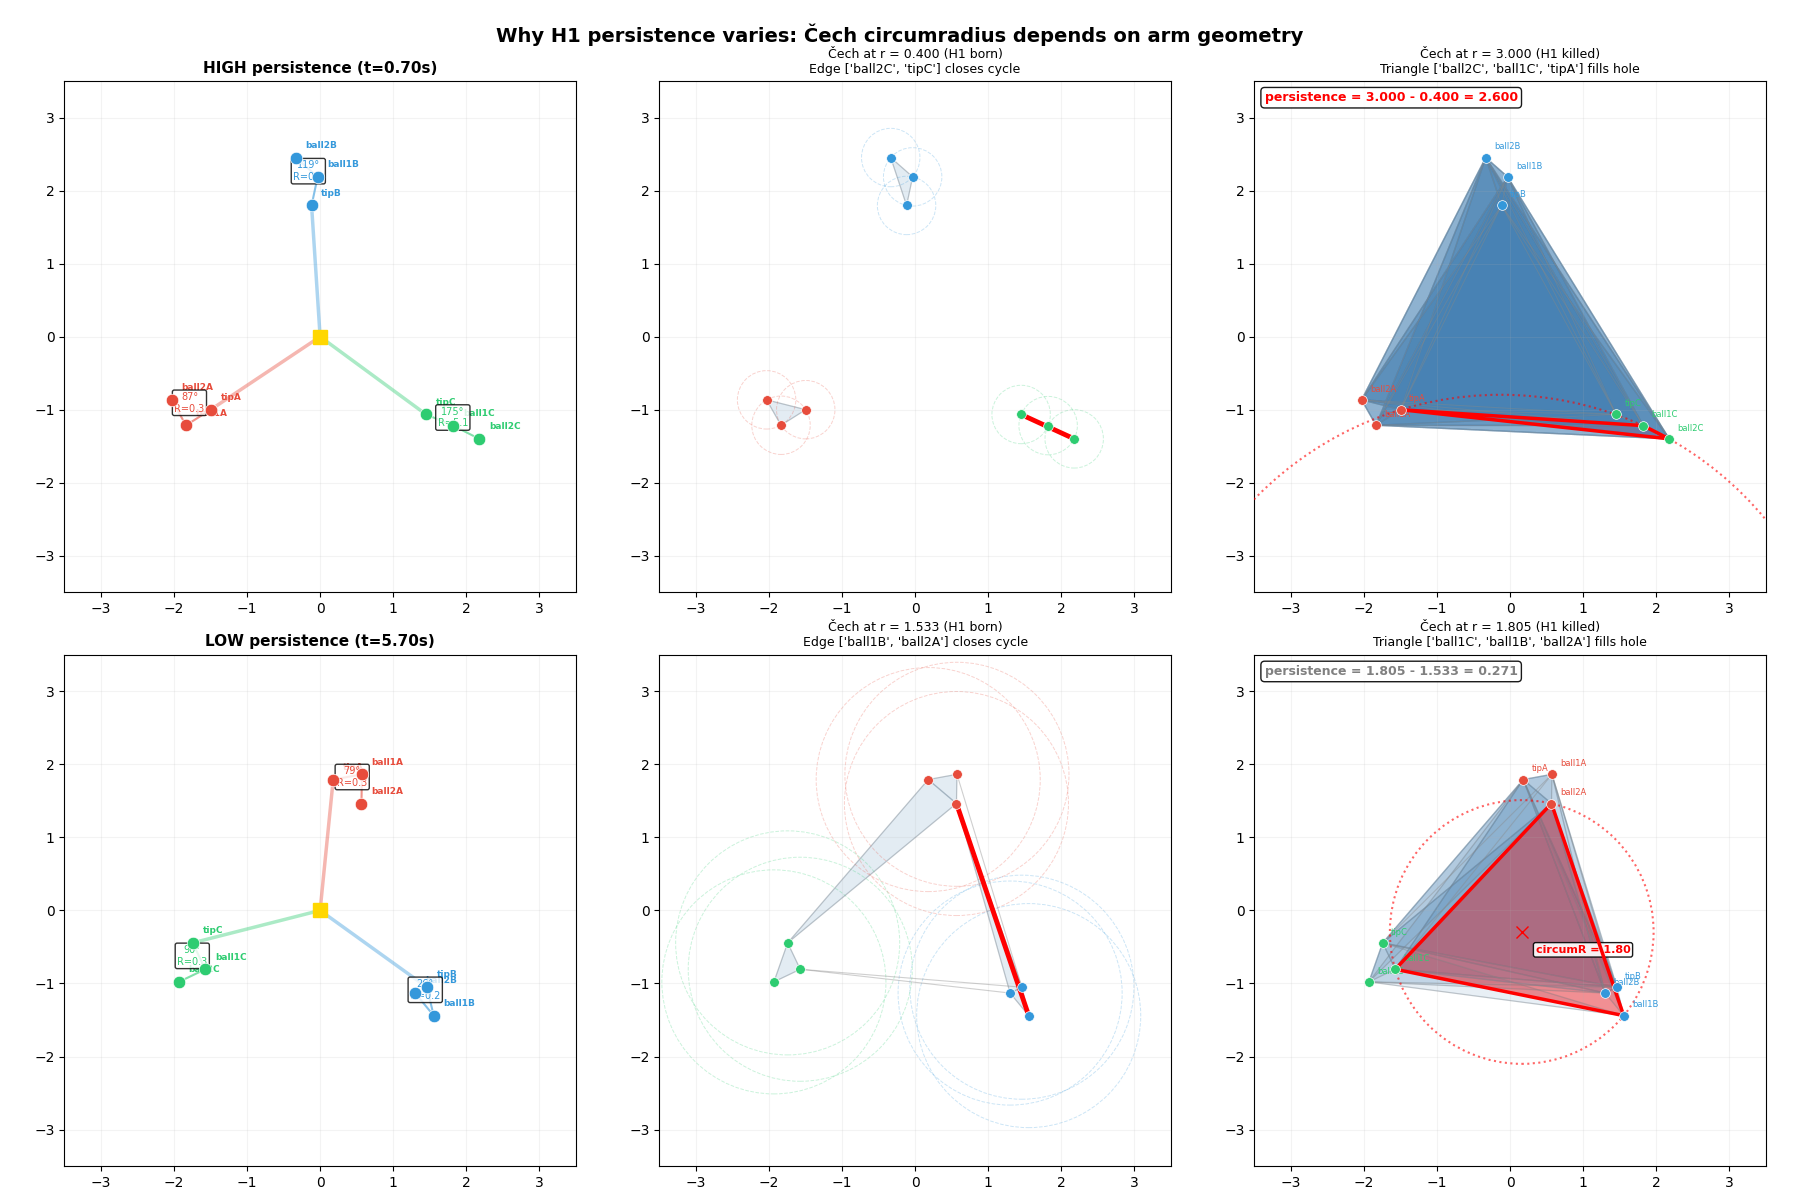


EXPLANATION:
  Top row (HIGH persistence, t=0.70s):
    - Arm C's balls are nearly collinear (angle=176°) → circumR=5.1
    - The killing triangle ball2C-ball1C-tipA has circumR=4.7 (clamped to 3.0)
    - Its circumcircle is HUGE, so it enters the Čech complex very late
    - The cycle lives from r=0.40 to r=3.00 → persistence=2.60

  Bottom row (LOW persistence, t=5.70s):
    - All arms are bent (angles 26°-90°) → circumR is small (0.2-0.3)
    - Killing triangles have small circumR → they enter early
    - The cycle barely lives → persistence≈0 (vine touches diagonal)

  Physical meaning: the vines track how "spread out" the pendulum is.
  When chains are stretched straight, the Čech hole persists.
  When chains are bent inward, the Čech hole collapses.



In [7]:
%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, Circle
from scipy.spatial.distance import pdist, squareform
import gudhi

# ─── Load data ───
df = pd.read_csv("star_pendulum_pointcloud.csv")
point_cols = [
    ("tipA_x", "tipA_y"), ("tipB_x", "tipB_y"), ("tipC_x", "tipC_y"),
    ("ball1A_x", "ball1A_y"), ("ball2A_x", "ball2A_y"),
    ("ball1B_x", "ball1B_y"), ("ball2B_x", "ball2B_y"),
    ("ball1C_x", "ball1C_y"), ("ball2C_x", "ball2C_y"),
]
names = [cx.replace('_x', '') for cx, cy in point_cols]
N_PTS = 9
MAX_RADIUS = 3.0
STEP = 10

frame_idx = list(range(0, len(df), STEP))
all_pts = np.zeros((len(frame_idx), N_PTS, 2))
for j, (cx, cy) in enumerate(point_cols):
    all_pts[:, j, 0] = df[cx].values[frame_idx]
    all_pts[:, j, 1] = df[cy].values[frame_idx]
all_dist = [squareform(pdist(pts)) for pts in all_pts]
times = df["time"].values[frame_idx]

def circumradius(p1, p2, p3):
    a, b, c = np.linalg.norm(p2 - p3), np.linalg.norm(p1 - p3), np.linalg.norm(p1 - p2)
    s = (a + b + c) / 2
    area = np.sqrt(max(s * (s - a) * (s - b) * (s - c), 0))
    return (a * b * c) / (4 * area) if area > 1e-12 else max(a, b, c) / 2

def circumcenter(p1, p2, p3):
    ax, ay = p1; bx, by = p2; cx, cy = p3
    D = 2 * (ax * (by - cy) + bx * (cy - ay) + cx * (ay - by))
    if abs(D) < 1e-12:
        return (p1 + p2 + p3) / 3
    ux = ((ax**2 + ay**2) * (by - cy) + (bx**2 + by**2) * (cy - ay) + (cx**2 + cy**2) * (ay - by)) / D
    uy = ((ax**2 + ay**2) * (cx - bx) + (bx**2 + by**2) * (ax - cx) + (cx**2 + cy**2) * (bx - ax)) / D
    return np.array([ux, uy])

def build_cech_st(pts, D):
    st = gudhi.SimplexTree()
    for i in range(N_PTS):
        st.insert([i], 0.0)
    for i in range(N_PTS):
        for j in range(i + 1, N_PTS):
            if D[i, j] / 2 <= MAX_RADIUS:
                st.insert([i, j], D[i, j] / 2)
    for i in range(N_PTS):
        for j in range(i + 1, N_PTS):
            for k in range(j + 1, N_PTS):
                mer = max(D[i, j], D[i, k], D[j, k]) / 2
                if mer <= MAX_RADIUS:
                    cr = circumradius(pts[i], pts[j], pts[k])
                    st.insert([i, j, k], min(max(cr, mer), MAX_RADIUS))
    st.make_filtration_non_decreasing()
    st.compute_persistence()
    return st

# ─── Identify the frames ───
# HIGH pers: frame 7 (t=0.70s), LOW pers: frame 57 (t=5.70s)
fi_high, fi_low = 7, 57

arm_colors = {'A': '#e74c3c', 'B': '#3498db', 'C': '#2ecc71'}
def point_color(name):
    for letter in ['A', 'B', 'C']:
        if letter in name:
            return arm_colors[letter]
    return 'gray'

# ─── Figure: 2 rows x 3 cols ───
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Why H1 persistence varies: Čech circumradius depends on arm geometry",
             fontsize=14, fontweight='bold')

for row_idx, (fi, label, pers_label) in enumerate([
    (fi_high, f"HIGH persistence (t={times[fi_high]:.2f}s)", "far from diagonal"),
    (fi_low,  f"LOW persistence (t={times[fi_low]:.2f}s)", "on the diagonal"),
]):
    pts = all_pts[fi]
    D = all_dist[fi]
    st = build_cech_st(pts, D)

    # Find the most persistent H1 pair
    best_pair = None
    best_pers = 0
    for pair in st.persistence_pairs():
        bsx, dsx = pair
        if len(bsx) == 2:
            bv, dv = st.filtration(bsx), st.filtration(dsx)
            if dv - bv > best_pers:
                best_pers = dv - bv
                best_pair = (bsx, dsx, bv, dv)

    birth_edge, death_tri, birth_val, death_val = best_pair

    # ── Column 1: Point configuration with pendulum structure ──
    ax = axes[row_idx, 0]
    ax.set_title(f"{label}", fontsize=11, fontweight='bold')
    ax.set_aspect('equal')

    # Draw rods from pivot to tips
    for i in range(3):
        tip = pts[i]
        c = point_color(names[i])
        ax.plot([0, tip[0]], [0, tip[1]], '-', color=c, lw=2.5, alpha=0.4, zorder=2)
    # Draw pendulum chains
    arms_idx = {'A': [0, 3, 4], 'B': [1, 5, 6], 'C': [2, 7, 8]}
    for arm_name, idxs in arms_idx.items():
        c = arm_colors[arm_name]
        for k in range(len(idxs) - 1):
            p0, p1 = pts[idxs[k]], pts[idxs[k + 1]]
            ax.plot([p0[0], p1[0]], [p0[1], p1[1]], '-', color=c, lw=1.5, alpha=0.6, zorder=2)

    # Draw points
    for i, (x, y) in enumerate(pts):
        c = point_color(names[i])
        ax.plot(x, y, 'o', color=c, markersize=9, zorder=5, markeredgecolor='white', markeredgewidth=0.5)
        ax.annotate(names[i], (x, y), textcoords="offset points",
                    xytext=(7, 7), fontsize=6.5, color=c, fontweight='bold')
    ax.plot(0, 0, 's', color='gold', markersize=10, zorder=6)

    # Show angle at ball1 for each arm
    for arm_name, idxs in arms_idx.items():
        p_tip, p_b1, p_b2 = pts[idxs[0]], pts[idxs[1]], pts[idxs[2]]
        v1, v2 = p_tip - p_b1, p_b2 - p_b1
        cos_a = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-12)
        angle = np.degrees(np.arccos(np.clip(cos_a, -1, 1)))
        cr = circumradius(p_tip, p_b1, p_b2)
        mid = (p_tip + p_b1 + p_b2) / 3
        ax.annotate(f"{angle:.0f}°\nR={cr:.1f}",
                    mid, fontsize=7, ha='center', color=arm_colors[arm_name],
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.grid(True, alpha=0.15)

    # ── Column 2: Čech complex at the birth filtration ──
    ax = axes[row_idx, 1]
    ax.set_title(f"Čech at r = {birth_val:.3f} (H1 born)\n"
                 f"Edge {[names[v] for v in birth_edge]} closes cycle",
                 fontsize=9)
    ax.set_aspect('equal')

    # Draw edges present at birth
    for i in range(N_PTS):
        for j in range(i + 1, N_PTS):
            edge_filt = D[i, j] / 2
            if edge_filt <= birth_val:
                is_birth = sorted([i, j]) == sorted(list(birth_edge))
                color = 'red' if is_birth else '#888888'
                lw = 3.5 if is_birth else 0.8
                ax.plot([pts[i, 0], pts[j, 0]], [pts[i, 1], pts[j, 1]],
                        '-', color=color, lw=lw, alpha=1.0 if is_birth else 0.4, zorder=3 if is_birth else 2)

    # Draw filled triangles at birth
    for i in range(N_PTS):
        for j in range(i + 1, N_PTS):
            for k in range(j + 1, N_PTS):
                mer = max(D[i, j], D[i, k], D[j, k]) / 2
                if mer <= MAX_RADIUS:
                    cr = circumradius(pts[i], pts[j], pts[k])
                    tf = min(max(cr, mer), MAX_RADIUS)
                    if tf <= birth_val:
                        tri = plt.Polygon([pts[i], pts[j], pts[k]],
                                          alpha=0.15, color='steelblue', zorder=1)
                        ax.add_patch(tri)

    # Draw Čech balls (circles) at radius = birth_val
    for i in range(N_PTS):
        circle = Circle(pts[i], birth_val, fill=False, linestyle='--',
                        edgecolor=point_color(names[i]), alpha=0.25, lw=0.7)
        ax.add_patch(circle)

    for i, (x, y) in enumerate(pts):
        ax.plot(x, y, 'o', color=point_color(names[i]), markersize=7, zorder=5,
                markeredgecolor='white', markeredgewidth=0.5)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.grid(True, alpha=0.15)

    # ── Column 3: Čech complex at the death filtration ──
    ax = axes[row_idx, 2]
    ax.set_title(f"Čech at r = {death_val:.3f} (H1 killed)\n"
                 f"Triangle {[names[v] for v in death_tri]} fills hole",
                 fontsize=9)
    ax.set_aspect('equal')

    # Draw edges at death
    for i in range(N_PTS):
        for j in range(i + 1, N_PTS):
            if D[i, j] / 2 <= death_val:
                ax.plot([pts[i, 0], pts[j, 0]], [pts[i, 1], pts[j, 1]],
                        '-', color='#888888', lw=0.8, alpha=0.4, zorder=2)

    # Draw filled triangles at death, highlight the killer
    for i in range(N_PTS):
        for j in range(i + 1, N_PTS):
            for k in range(j + 1, N_PTS):
                mer = max(D[i, j], D[i, k], D[j, k]) / 2
                if mer <= MAX_RADIUS:
                    cr = circumradius(pts[i], pts[j], pts[k])
                    tf = min(max(cr, mer), MAX_RADIUS)
                    if tf <= death_val:
                        is_killer = sorted([i, j, k]) == sorted(list(death_tri))
                        color = 'red' if is_killer else 'steelblue'
                        alpha = 0.4 if is_killer else 0.12
                        tri = plt.Polygon([pts[i], pts[j], pts[k]],
                                          alpha=alpha, color=color, zorder=1)
                        ax.add_patch(tri)
                        if is_killer:
                            tri_b = plt.Polygon([pts[i], pts[j], pts[k]],
                                                fill=False, edgecolor='red', lw=2.5, zorder=4)
                            ax.add_patch(tri_b)
                            # Draw circumcircle of the killing triangle
                            cc = circumcenter(pts[i], pts[j], pts[k])
                            cr_val = circumradius(pts[i], pts[j], pts[k])
                            circ = Circle(cc, cr_val, fill=False, edgecolor='red',
                                          linestyle=':', lw=1.5, alpha=0.6, zorder=3)
                            ax.add_patch(circ)
                            ax.plot(*cc, 'x', color='red', markersize=8, zorder=6)
                            ax.annotate(f"circumR = {cr_val:.2f}",
                                        cc, textcoords="offset points", xytext=(10, -15),
                                        fontsize=8, color='red', fontweight='bold',
                                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))

    for i, (x, y) in enumerate(pts):
        ax.plot(x, y, 'o', color=point_color(names[i]), markersize=7, zorder=5,
                markeredgecolor='white', markeredgewidth=0.5)
        ax.annotate(names[i], (x, y), textcoords="offset points",
                    xytext=(6, 6), fontsize=6, color=point_color(names[i]))
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.grid(True, alpha=0.15)

    # Persistence annotation
    ax.text(0.02, 0.98, f"persistence = {death_val:.3f} - {birth_val:.3f} = {best_pers:.3f}",
            transform=ax.transAxes, fontsize=9, va='top',
            color='red' if best_pers > 0.5 else 'gray', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()

print("""
EXPLANATION:
  Top row (HIGH persistence, t=0.70s):
    - Arm C's balls are nearly collinear (angle=176°) → circumR=5.1
    - The killing triangle ball2C-ball1C-tipA has circumR=4.7 (clamped to 3.0)
    - Its circumcircle is HUGE, so it enters the Čech complex very late
    - The cycle lives from r=0.40 to r=3.00 → persistence=2.60

  Bottom row (LOW persistence, t=5.70s):
    - All arms are bent (angles 26°-90°) → circumR is small (0.2-0.3)
    - Killing triangles have small circumR → they enter early
    - The cycle barely lives → persistence≈0 (vine touches diagonal)

  Physical meaning: the vines track how "spread out" the pendulum is.
  When chains are stretched straight, the Čech hole persists.
  When chains are bent inward, the Čech hole collapses.
""")